# ДИПЛОМНАЯ РАБОТА

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import hashlib
import scipy.stats as st
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu

### Загрузка и первичный анализ данных

In [2]:
# Загружаем данные в отдельные DataFrame
file_path = 'Новый диплом датасет update.xlsx'

df_data = pd.read_excel(file_path, sheet_name = 'Данные')
df_clients = pd.read_excel(file_path, sheet_name = 'Clients')
df_regions = pd.read_excel(file_path, sheet_name = 'Region_dict')

# Выводим первые строки и общую информацию
print('---Основные данные теста---')
display(df_data.head())

print('\n---Справочник клиентов---')
display(df_clients.head())

print('\n---Справочник регионов---')
display(df_regions.head())

---Основные данные теста---


,id_order,id_client,amt_payment,dtime_pay
0,100238,194569.0,5373.0,2022-07-17 21:48:15.896
1,100242,191056.0,4151.0,2022-07-07 03:09:39.699
2,100249,200049.0,5688.0,2022-07-29 13:25:59.976
3,100258,206161.0,4330.0,2022-08-15 22:55:02.538
4,100267,190945.0,5488.0,2022-07-05 19:46:47.174



---Справочник клиентов---


,id_client,dtime_ad,nflag_test,id_trading_point
0,180844,2022-06-08 18:38:41.414,0,212
1,193942,NaT,0,13
2,226069,2022-07-11 16:28:38.511,1,54
3,183981,2022-06-16 12:23:59.289,1,991
4,322530,2022-07-08 08:56:08.714,0,1015



---Справочник регионов---


,id_trading_point,city
0,1,Петрозаводск
1,2,Дмитров
2,4,Чехов
3,7,Ростов Великий
4,11,Владимир


In [3]:
def check_up (data):
    print(f'Размер данных: {data.shape}') # Проверяем размер таблицы
    print(f'Общие дубликаты: {data.duplicated().sum()}') # Проверяем на общие дубликаты
    print('-'*30)
    print(f'Пропуски по столбцам:\n{data.isna().sum()}')# Проверяем наличие пропусков
    print('-'*30) 
    data.info()

In [4]:
tab = [df_data, df_clients, df_regions]
name = ['Основные данные', 'Справочник клиентов', 'Справочник регионов']
n = 0
for i in tab:
    print(name[n])
    n += 1
    check_up (i) 
    print('-'*100)     

Основные данные
Размер данных: (37989, 4)
Общие дубликаты: 0
------------------------------
Пропуски по столбцам:
id_order          0
id_client       588
amt_payment    2144
dtime_pay      2429
dtype: int64
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37989 entries, 0 to 37988
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_order     37989 non-null  int64         
 1   id_client    37401 non-null  float64       
 2   amt_payment  35845 non-null  float64       
 3   dtime_pay    35560 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 1.2 MB
----------------------------------------------------------------------------------------------------
Справочник клиентов
Размер данных: (55605, 4)
Общие дубликаты: 0
------------------------------
Пропуски по столбцам:
id_client             0
dtime_ad            249
nflag_test            0


**Анализ и обработка пропущенных значений**
1. В таблице df_data в столбце **amt_payment 2144 пропуска, а dtime_pay 2429**:скорее всего покупатель не совершил покупку, поэтому **Заменим NaN** на **0**.
2. В таблице df_data в столбце **id_client 588 пропусков**: мы не сможем подтянуть данные из других таблиц к пустому id_client, и так как этих пропусков < 10%, просто **удаляем** строки с пустым id_client.
3. В df_clients в столбце  **dtime_ad 249 пропусков**: Отсутствует время показа рекламы. Так как данных менее 10%, их **удаление** не повлияет на точность теста.

In [5]:
# Заменяем NaN на 0 в столбце amt_payment таблицы df_data 
df_data['amt_payment'] = df_data['amt_payment'].fillna(0)

# Заменяем NaN на 0 в столбце dtime_pay таблицы df_data 
df_data['dtime_pay'] = df_data['dtime_pay'].fillna(0)

# Удаляем строки, с пустыми id_client таблицы df_data 
df_data = df_data.dropna(subset=['id_client'])
df_clients = df_clients.dropna(subset=['dtime_ad'])

In [6]:
# Проверяем
tab = [df_data, df_clients, df_regions]
name = ['Основные данные', 'Справочник клиентов', 'Справочник регионов']
n = 0
for i in tab:
    print(name[n])
    n += 1
    check_up (i) 
    print('-'*100) 

Основные данные
Размер данных: (37401, 4)
Общие дубликаты: 0
------------------------------
Пропуски по столбцам:
id_order       0
id_client      0
amt_payment    0
dtime_pay      0
dtype: int64
------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 37401 entries, 0 to 37988
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_order     37401 non-null  int64  
 1   id_client    37401 non-null  float64
 2   amt_payment  37401 non-null  float64
 3   dtime_pay    37401 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 1.4+ MB
----------------------------------------------------------------------------------------------------
Справочник клиентов
Размер данных: (55356, 4)
Общие дубликаты: 0
------------------------------
Пропуски по столбцам:
id_client           0
dtime_ad            0
nflag_test          0
id_trading_point    0
dtype: int64
------------------------------
<class

In [7]:
# Посмотрим на количество торговых точек в каждом городе
city_points = df_regions['city'].value_counts()
print('Количество торговых точек по городам')
print(city_points)

Количество торговых точек по городам
city
Москва              11
Санкт-Петербург     11
Казань               6
Новосибирск          6
Красноярск           5
Самара               4
Краснодар            4
Саратов              2
Сочи                 2
Мурманск             2
Владимир             1
Чехов                1
Дмитров              1
Петрозаводск         1
Ростов Великий       1
Тюмень               1
Нижний Новгород      1
Сахалинск            1
Ярославль            1
Великий Новгород     1
Волгоград            1
Ростов-на-Дону       1
Тольятти             1
Name: count, dtype: int64


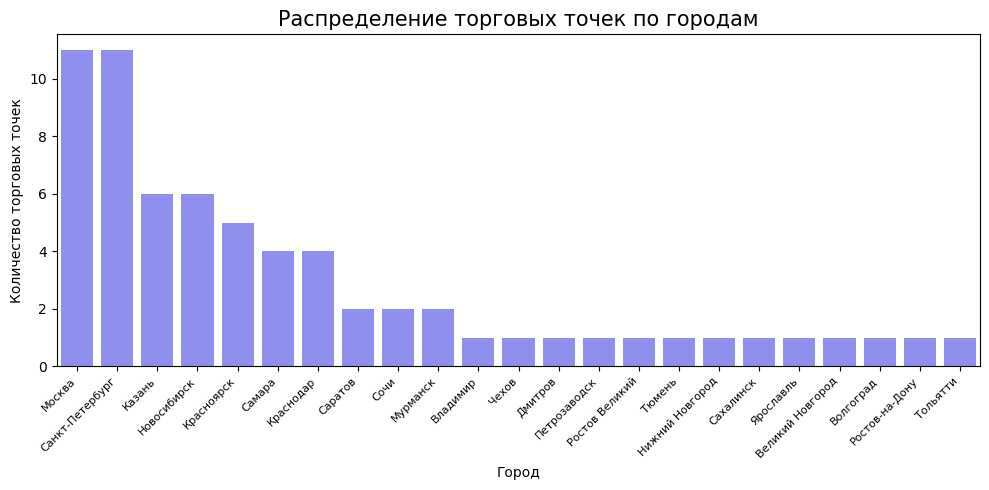

In [8]:
# Строим столбчатую диаграмму количества торговых точек в городах
plt.figure(figsize = (10, 5))
sns.countplot(data=df_regions, x='city', order=df_regions['city'].value_counts().index, color='blue', alpha=0.5)
plt.title('Распределение торговых точек по городам', fontsize=15)
plt.xlabel('Город', fontsize=10)
plt.ylabel('Количество торговых точек')

plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

### Объединение таблиц

Так как один и тот же покупатель мог совершить несколько покупок, прежде чем объединять таблицы, сгруппируем основную таблицу по пользователям с агрегацией платежей в сумму.

In [9]:
# Группируем покупателей
df_data_gr = df_data.groupby('id_client').agg(sum_pay = ('amt_payment', 'sum'),
                                             cnt_pay = ('id_order', 'count'),
                                             dtime_pay = ('dtime_pay', 'first')).reset_index()
df_data_gr.head()

,id_client,sum_pay,cnt_pay,dtime_pay
0,178561.0,3052.0,1,2022-06-05 02:47:49.183000
1,178562.0,2439.0,1,2022-06-04 02:51:21.878000
2,178563.0,768.0,1,2022-06-04 02:52:10.616000
3,178564.0,0.0,2,0
4,178565.0,958.0,1,2022-06-05 02:55:13.525000


In [10]:
check_up (df_data_gr)

Размер данных: (29712, 4)
Общие дубликаты: 0
------------------------------
Пропуски по столбцам:
id_client    0
sum_pay      0
cnt_pay      0
dtime_pay    0
dtype: int64
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29712 entries, 0 to 29711
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id_client  29712 non-null  float64
 1   sum_pay    29712 non-null  float64
 2   cnt_pay    29712 non-null  int64  
 3   dtime_pay  29712 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 928.6+ KB


In [11]:
# Объединяем сгруппированную основную таблицу со справочником клиентов (по клиентам в справочнике)
df = df_data_gr.merge(df_clients, on='id_client',how='right') 

# Там, где нет информации по платежам (не было покупки), заменяем NaN на 0 в столбце sum_pay 
df['sum_pay'] = df['sum_pay'].fillna(0)

# Заменяем NaN на 0 в столбце dtime_pay 
df['dtime_pay'] = df['dtime_pay'].fillna(0)

# Заменяем NaN на 0 в столбце cnt_pay	
df['cnt_pay'] = df['cnt_pay'].fillna(0)
df.head()

,id_client,sum_pay,cnt_pay,dtime_pay,dtime_ad,nflag_test,id_trading_point
0,180844.0,5349.0,1.0,2022-06-10 18:38:41.414000,2022-06-08 18:38:41.414,0,212
1,226069.0,0.0,0.0,0,2022-07-11 16:28:38.511,1,54
2,183981.0,6322.0,2.0,2022-06-17 12:23:59.289000,2022-06-16 12:23:59.289,1,991
3,322530.0,0.0,0.0,0,2022-07-08 08:56:08.714,0,1015
4,254313.0,0.0,0.0,0,2022-06-19 22:18:01.770,1,453


In [12]:
check_up (df)

Размер данных: (55356, 7)
Общие дубликаты: 0
------------------------------
Пропуски по столбцам:
id_client           0
sum_pay             0
cnt_pay             0
dtime_pay           0
dtime_ad            0
nflag_test          0
id_trading_point    0
dtype: int64
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55356 entries, 0 to 55355
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_client         55356 non-null  float64       
 1   sum_pay           55356 non-null  float64       
 2   cnt_pay           55356 non-null  float64       
 3   dtime_pay         55356 non-null  object        
 4   dtime_ad          55356 non-null  datetime64[ns]
 5   nflag_test        55356 non-null  int64         
 6   id_trading_point  55356 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(2), object(1)
memory usage: 3.0+ MB


In [13]:
# Далее присоединяем справочник регионов
df = df.merge(df_regions, on='id_trading_point',how='left')
print('Финальная таблица')
df.head()

Финальная таблица


,id_client,sum_pay,cnt_pay,dtime_pay,dtime_ad,nflag_test,id_trading_point,city
0,180844.0,5349.0,1.0,2022-06-10 18:38:41.414000,2022-06-08 18:38:41.414,0,212,Красноярск
1,226069.0,0.0,0.0,0,2022-07-11 16:28:38.511,1,54,Мурманск
2,183981.0,6322.0,2.0,2022-06-17 12:23:59.289000,2022-06-16 12:23:59.289,1,991,Казань
3,322530.0,0.0,0.0,0,2022-07-08 08:56:08.714,0,1015,Краснодар
4,254313.0,0.0,0.0,0,2022-06-19 22:18:01.770,1,453,Санкт-Петербург


In [14]:
check_up (df)

Размер данных: (55356, 8)
Общие дубликаты: 0
------------------------------
Пропуски по столбцам:
id_client           0
sum_pay             0
cnt_pay             0
dtime_pay           0
dtime_ad            0
nflag_test          0
id_trading_point    0
city                0
dtype: int64
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55356 entries, 0 to 55355
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_client         55356 non-null  float64       
 1   sum_pay           55356 non-null  float64       
 2   cnt_pay           55356 non-null  float64       
 3   dtime_pay         55356 non-null  object        
 4   dtime_ad          55356 non-null  datetime64[ns]
 5   nflag_test        55356 non-null  int64         
 6   id_trading_point  55356 non-null  int64         
 7   city              55356 non-null  object        
dtypes: datetime64[ns](1), float64

In [15]:
# Проверим на наличие пользователей, попавших в обе группы
duplicates = df.groupby('id_client')['nflag_test'].nunique() # Проверяем пользователей, попавших в обе группы
print(f'Пользователей в обеих группах:{duplicates[duplicates >1].count()}')
print('-'*30)

Пользователей в обеих группах:0
------------------------------


Данные приведены в порядок. Видим, что количество строк (55605) совпадает с количеством строк Справочника клиентов, значит все клиенты попали в нашу финальную таблицу.

In [16]:
# Для расчета конверсии, создадим флаг покупки (1-купил, 0-не купил)
df['is_bought'] = df['sum_pay'].apply(lambda x: 1 if x > 0 else 0)
df.head()

,id_client,sum_pay,cnt_pay,dtime_pay,dtime_ad,nflag_test,id_trading_point,city,is_bought
0,180844.0,5349.0,1.0,2022-06-10 18:38:41.414000,2022-06-08 18:38:41.414,0,212,Красноярск,1
1,226069.0,0.0,0.0,0,2022-07-11 16:28:38.511,1,54,Мурманск,0
2,183981.0,6322.0,2.0,2022-06-17 12:23:59.289000,2022-06-16 12:23:59.289,1,991,Казань,1
3,322530.0,0.0,0.0,0,2022-07-08 08:56:08.714,0,1015,Краснодар,0
4,254313.0,0.0,0.0,0,2022-06-19 22:18:01.770,1,453,Санкт-Петербург,0


### Чистка неверно заполненных точек

Определим и очистим даннные от торговых точек с нулевой выручкой и от тех, где была только одна группа (тестовая или контрольная), чтобы они не исказили статистику A/B теста.

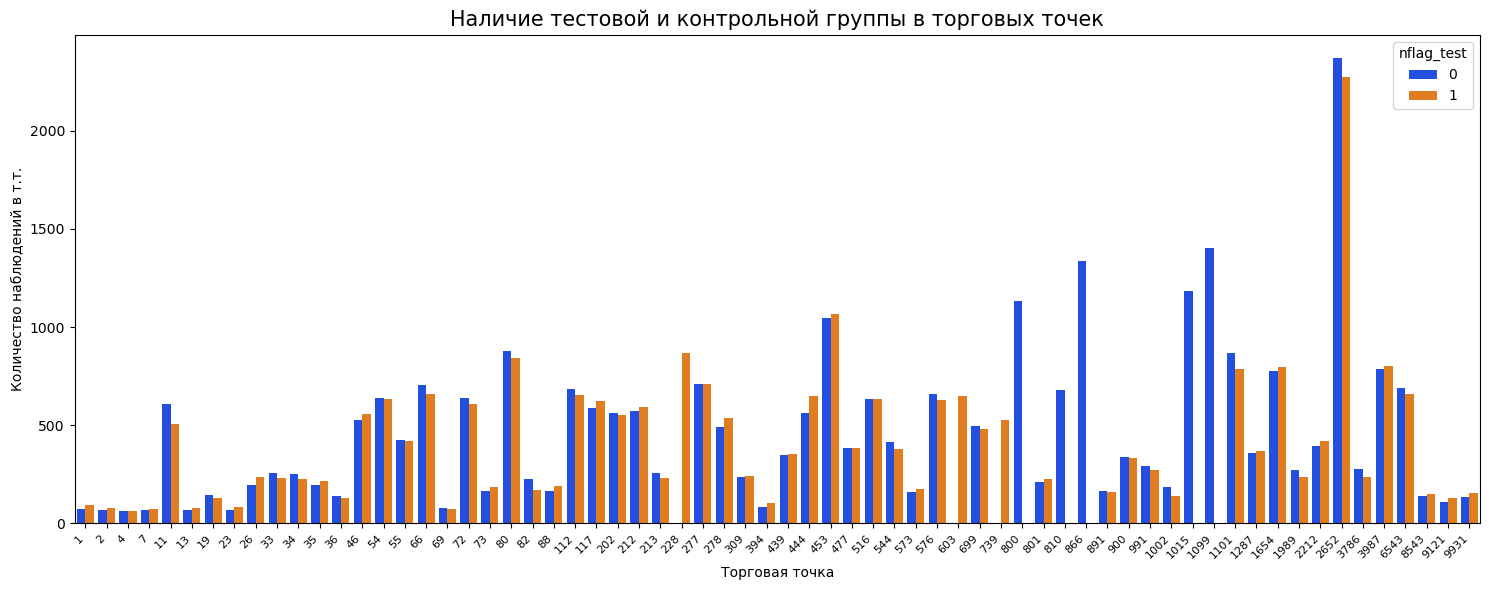

In [17]:
# Строим столбчатую диаграмму с количеством наблюдений в тестовой и контрольной группе для каждой торговой точки(т.т.)
plt.figure(figsize = (15, 6))
sns.countplot(data=df, x='id_trading_point', palette= 'bright', hue='nflag_test')
plt.title('Наличие тестовой и контрольной группы в торговых точек', fontsize=15)
plt.xlabel('Торговая точка', fontsize=10)
plt.ylabel('Количество наблюдений в т.т.')

plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

Награфике видим, что есть торговые точки, где присутствует только одна группа (тестовая или контрольная). В них мы физически не сможем провести сравнение, поэтому необходимо их вывести из анализа.

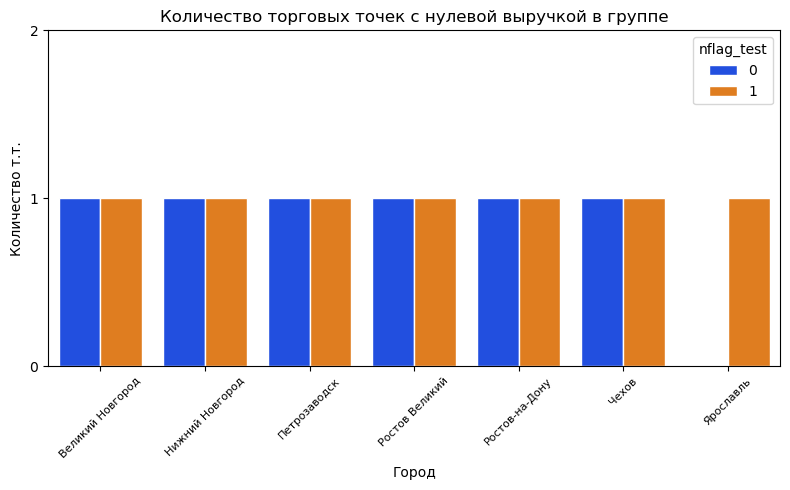

In [18]:
tp_revenue = df.groupby(['city', 'id_trading_point', 'nflag_test'])['sum_pay'].sum().reset_index()
zero_revenue = tp_revenue[tp_revenue['sum_pay'] ==0]
zero_cnt = zero_revenue.groupby(['city', 'nflag_test'])['id_trading_point'].count().reset_index()
zero_cnt.columns = ['city', 'nflag_test', 'cnt_zero_tp']

plt.figure(figsize = (8,5))
sns.barplot(data=zero_cnt, x='city', y='cnt_zero_tp', palette= 'bright', edgecolor='white',  hue='nflag_test')
plt.title('Количество торговых точек с нулевой выручкой в группе', fontsize=12)
plt.xlabel('Город', fontsize=10)
plt.ylabel('Количество т.т.')

plt.xticks(rotation=45, fontsize=8)
plt.yticks([0, 1, 2])
plt.tight_layout()
plt.show()

Награфике видим, что в 7 городах есть по одной торговой токи, где отсутствует выручка: в 6 точках выручки нет и в  тестовой и в контрольной группе, в Ярославле - нет выручки только в тестевой группе.Мы не можем провести сравнение чеков и коныерсии, поэтому необходимо удалить данные по этим торговы мточкам.

Проверим наши выводы через код

In [19]:
# Готовим пустые списки
points_no_group = [] # для точек, где не хватает группы
points_no_many = [] # для точек с 0 выручкой в группе

# Создадим список всех уникальных торговых точек (т.т.)
all_points = df['id_trading_point'].unique()

# Запускаем цикл по каждой торговой точке
for point in all_points:
    point_data = df[df['id_trading_point'] == point] # фильтруем данные по конкретной т.т.


    # Проверяем на наличие двух групп
    if point_data['nflag_test'].nunique() < 2: 
        points_no_group.append(point)
        
    # Проверяем по выручке 
    else:
        rev_gr_0 = point_data[point_data['nflag_test']==0]['sum_pay'].sum()
        rev_gr_1 = point_data[point_data['nflag_test']==1]['sum_pay'].sum()
        if rev_gr_0 ==0 or rev_gr_1 == 0 :
            points_no_many.append(point)
      
        
# Объединяем найденные т.т. в общий set (без дубликатов)
bad_points = list(set(points_no_group+points_no_many))

print(f'Количество точек с одной группой: {len(points_no_group)}')
print(f'Количество точек без выручки в группе: {len(points_no_many)}')
print(f'Всего исключаем количество уникальных точек: {len(bad_points)}')

Количество точек с одной группой: 8
Количество точек без выручки в группе: 7
Всего исключаем количество уникальных точек: 15


In [20]:
# Очистим данные от неверно заполненных точек
df_clean = df[~df['id_trading_point'].isin(bad_points)]
print(f'Всего строк до очистки точек: {len(df)}')
print(f'Всего строк после очистки точек: {len(df_clean)}')

Всего строк до очистки точек: 55356
Всего строк после очистки точек: 45318


### Расчет общих результатов A/B-теста

Посмотрим на распределение платежей в контрольной и тестовой группах во всех городах

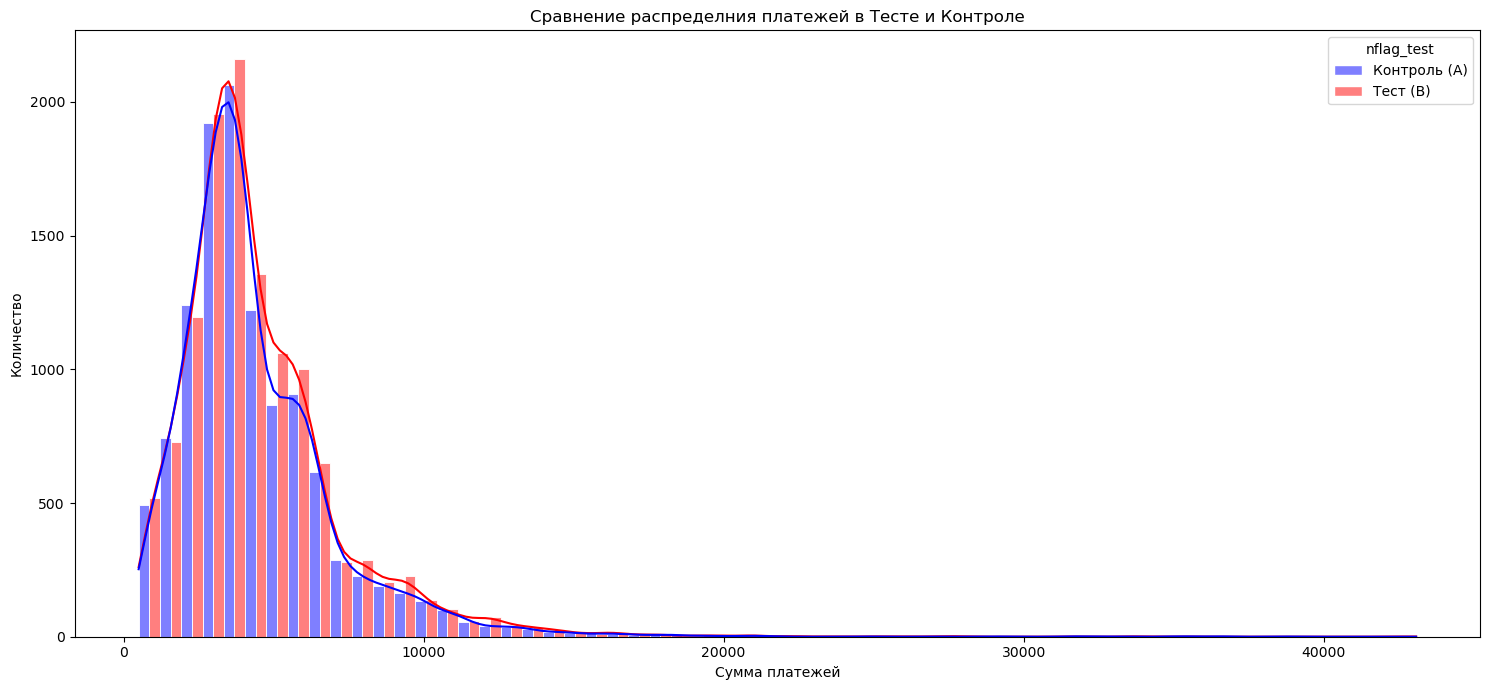

In [21]:
# Строим гистограмму распределния платежей 
plot_pay = df_clean[df_clean['sum_pay'] > 0] # берем данные, где был платеж
plot_df = plot_pay.copy()
plot_df['nflag_test'] = plot_df['nflag_test'].map({0:'Контроль (А)', 1:'Тест (В)'})
plt.figure(figsize=(15, 7))
sns.histplot(data=plot_df, 
             x='sum_pay', 
             hue='nflag_test', 
             bins=60, 
             palette={'Контроль (А)':'blue', 'Тест (В)':'red'}, 
             alpha=0.5, 
             edgecolor='white', 
             multiple='dodge',
             kde = True)

plt.title('Сравнение распределния платежей в Тесте и Контроле')
plt.xlabel('Сумма платежей')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

Посмотрим на конверсию группах в целом по всем данным теста

In [22]:
# Преобразуем данные в сводную таблицу
pd.options.display.float_format = '{:.2f}'.format
df_ab = df_clean.pivot_table(index = 'nflag_test',
                             values = ['id_client', 'is_bought', 'sum_pay'],
                             aggfunc = {'id_client':'nunique', # кол-во уникальных покупателей
                                        'is_bought':'sum',   # кол-во покупок в группе
                                        'sum_pay':['mean','sum']} # средний чек и выручка
                            ).T # транспонируем сводную таблицу
# Переименуем столбцы и строки
df_ab.index = ['total_users', 'total_purchases', 'avg_check', 'total_revenue']
df_ab.columns = ['control(А)', 'test(В)']

# Определяем конверсию в отдельную строку 
df_ab.loc['conversion,%'] = (df_ab.loc['total_purchases']/df_ab.loc['total_users']*100)

# Добавим разницу и рост метрик
df_ab['delta'] = df_ab['test(В)'] - df_ab['control(А)'] 
df_ab['growth'] = (df_ab['delta']/df_ab['control(А)'])*100 

display(df_ab)

,control(А),test(В),delta,growth
total_users,22873.00,22445.00,-428.00,-1.87
total_purchases,11431.00,12207.00,776.00,6.79
avg_check,2189.19,2455.58,266.40,12.17
total_revenue,50073307.00,55115596.00,5042289.00,10.07
"conversion,%",49.98,54.39,4.41,8.82


<div class="alert alert-block alert-info">
<b>Вывод:</b>
<ul> 
    <li> На графике видно, что платежи в тестовой группе (красные столбики) стабильно выше платежей в контрольной группе (синие столбики) в диапазоне чеков (или их сумм) выше 4-5т.р.</li>
    <li> То есть, пуш-уведомления не только увеличили общую выручку на 10,07% (с 50,07 до 55,12 млн.руб.) но и стимулировали клиентов покупать чаще и на большие суммы.</li>
    <li> Это привело к увеличению общей конверсии в покупку более чем на 4 п.п.</li>
</ul>
</div>

Проверим наши выводы, проведя статистические вычисления

 #### Автоматизация статистических вычислений

In [23]:
# Создаем функцию расчета стат. критерия и p-value для сравнения средних чеков и конверсии
def test_calc (r1, r2, pvalue=0.05):
    print('Разница между средними значениями:', round(r1.mean()-r2.mean(), 2))
    print('Количество наблюдений первой выборки', len(r1))
    print('Количество наблюдений второй выборки',len(r2))
    s, p_st = ttest_ind(r1, r2)
    print('Стат.критерий:', s)
    print('p value:', p_st)
    if p_st <= pvalue:
        print('Разница статистически значима')
    else:
        print('Разница статистически НЕ значима') 
    return s, p_st

In [24]:
# Создаем функцию рассчета критерия Манна Уитни и p-value для сравнения распределений  
def mann_whitney_func (r1, r2, pvalue=0.05):
    u, p_mw = mannwhitneyu(r1, r2)
    print('Стат.критерий:', u)
    print('p value:', p_mw)
    if p_mw <= pvalue:
        print('Разница в выборках статистически значима')
    else:
        print('Нет стат. значимой разницы между выборками')  
    return u, p_mw    

##### Сравнение средних чеков в контрольной и тестовой группах

In [25]:
# Отфильтруем данные с платежами по группам
control_pay = df_clean[(df_clean['nflag_test'] == 0)]['sum_pay'] 
test_pay = df_clean[(df_clean['nflag_test'] == 1)]['sum_pay']  

print('---Сравнение средних чеков---')
test_calc(test_pay, control_pay)

---Сравнение средних чеков---
Разница между средними значениями: 266.4
Количество наблюдений первой выборки 22445
Количество наблюдений второй выборки 22873
Стат.критерий: 9.573285274103036
p value: 1.0857547123769503e-21
Разница статистически значима


(np.float64(9.573285274103036), np.float64(1.0857547123769503e-21))

##### Сравнение коверсии в контрольной и тестовой группах

In [26]:
# Отфильтруем данные по группам и сравниваем данные флага в покупку 
control_conv = df_clean[df_clean['nflag_test'] == 0]['is_bought'] 
test_conv = df_clean[df_clean['nflag_test'] == 1]['is_bought'] 

print('---Сравнение конверсии---')
test_calc(test_conv, control_conv)

---Сравнение конверсии---
Разница между средними значениями: 0.04
Количество наблюдений первой выборки 22445
Количество наблюдений второй выборки 22873
Стат.критерий: 9.406024876422881
p value: 5.384854454774238e-21
Разница статистически значима


(np.float64(9.406024876422881), np.float64(5.384854454774238e-21))

##### Сравнение распределения платежей в контрольной и тестовой группах

In [27]:
print('---Тест Манна-Уитни для плптежей---')
mann_whitney_func(test_pay, control_pay)

---Тест Манна-Уитни для плптежей---
Стат.критерий: 270212972.5
p value: 7.829376257720135e-25
Разница в выборках статистически значима


(np.float64(270212972.5), np.float64(7.829376257720135e-25))

<div class="alert alert-block alert-info">
<b>По результатам проведенных вычислений, видим, что полученные различия в группах не случайны:</b>
<ul> 
    <li> p-value для среднего чека, конверсии, а также для критерия Манна-Уитни значительно меньше уровня значимости (0,05), что позволяет нам отвергнуть нулевую гипотезу об их равенстве. </li>
      <li> различия статистически значимы, то есть пуш-уведомления положительно повлияли на бизнес-метрики в целом на  весь ретейлер SkyLenta. </li>
</ul>
</div>

Посмотрим, изменятся ли результаты теста после сегментации данных по городам.

#### Сегментация результатов A/B-теста

In [28]:
pd.options.display.float_format = '{:.2f}'.format
segm_pivot = df_clean.pivot_table(index = ['city', 'nflag_test'],
                                  values = ['id_client', 'is_bought', 'sum_pay'],
                                  aggfunc = {'id_client':'nunique', # кол-во уникальных покупателей
                                             'is_bought':'sum',   # кол-во покупок в группе
                                             'sum_pay':'sum'} # средний чек и выручка
                                 )
# Переименуем столбцы и строки
segm_pivot.columns = ['users', 'purchases', 'revenue']

# Определяем средний чек в отдельный столбец 
segm_pivot['avg_check'] = segm_pivot['revenue']/segm_pivot['purchases']

# Определяем конверсию в отдельный столбец 
segm_pivot['conversion,%'] = segm_pivot['purchases']/segm_pivot['users']*100



segm_pivot

users  purchases     revenue  avg_check  \
city            nflag_test                                            
Владимир        0             608        303  1282035.00    4231.14   
                1             509        280  1296535.00    4630.48   
Волгоград       0             703        419  1829038.00    4365.25   
                1             657        363  1503788.00    4142.67   
Дмитров         0              71          7    34325.00    4903.57   
                1              78          9    45188.00    5020.89   
Казань          0            2577       1224  6727744.00    5496.52   
                1            2500       1197  6834855.00    5709.99   
Краснодар       0            1139        744  3317259.00    4458.68   
                1            1024        629  2761528.00    4390.35   
Красноярск      0            2900       1628  7043455.00    4326.45   
                1            3037       1694  7402675.00    4369.94   
Москва          0            6224       3037 12361988.00    4070.46   
                1            6134       3347 14594220.00    4360.39   
Мурманск        0            1065        446  1977939.00    4434.84   
                1            1055        461  1967861.00    4268.68   
Самара          0             846        372  1453781.00    3908.01   
                1             802        575  2616757.00    4550.88   
Санкт-Петербург 0            4434       1988  8484719.00    4267.97   
                1            4445       2432 10790071.00    4436.71   
Саратов         0            1109        637  2818685.00    4424.94   
                1            1013        596  2561663.00    4298.09   
Сахалинск       0              78         11    46812.00    4255.64   
                1              75         16    87859.00    5491.19   
Сочи            0             806        463  2033604.00    4392.23   
                1             796        418  1835441.00    4391.01   
Тольятти        0             167         97   407390.00    4199.90   
                1             190        122   551458.00    4520.15   
Тюмень          0             146         55   254533.00    4627.87   
                1             130         68   265697.00    3907.31   

                            conversion,%  
city            nflag_test                
Владимир        0                  49.84  
                1                  55.01  
Волгоград       0                  59.60  
                1                  55.25  
Дмитров         0                   9.86  
                1                  11.54  
Казань          0                  47.50  
                1                  47.88  
Краснодар       0                  65.32  
                1                  61.43  
Красноярск      0                  56.14  
                1                  55.78  
Москва          0                  48.79  
                1                  54.56  
Мурманск        0                  41.88  
                1                  43.70  
Самара          0                  43.97  
                1                  71.70  
Санкт-Петербург 0                  44.84  
                1                  54.71  
Саратов         0                  57.44  
                1                  58.84  
Сахалинск       0                  14.10  
                1                  21.33  
Сочи            0                  57.44  
                1                  52.51  
Тольятти        0                  58.08  
                1                  64.21  
Тюмень          0                  37.67  
                1                  52.31

In [29]:
# Проведем стат.анализ в отношении Москвы
df_Msc = df_clean[df_clean['city'] == 'Москва'] # фильтруем по Москве

print(f'---Тест для города Москва---')
control_pay_Msc = df_Msc[(df_Msc['nflag_test'] == 0)]['sum_pay']
test_pay_Msc = df_Msc[(df_Msc['nflag_test'] == 1)]['sum_pay']

print('---Сравнение средних чеков---')
test_calc(test_pay_Msc, control_pay_Msc)
print()

control_conv_Msс = df_Msc[df_Msc['nflag_test'] == 0]['is_bought']
test_conv_Msс = df_Msc[df_Msc['nflag_test'] == 1]['is_bought']
print('---Сравнение конверсий---')
test_calc(test_conv_Msс, control_conv_Msс)
print()

print('---Сравнение распределение платежей---')
mann_whitney_func(test_pay_Msc, control_pay_Msc)

---Тест для города Москва---
---Сравнение средних чеков---
Разница между средними значениями: 393.05
Количество наблюдений первой выборки 6134
Количество наблюдений второй выборки 6224
Стат.критерий: 7.896238614943354
p value: 3.116649629630609e-15
Разница статистически значима

---Сравнение конверсий---
Разница между средними значениями: 0.06
Количество наблюдений первой выборки 6134
Количество наблюдений второй выборки 6224
Стат.критерий: 6.427576036124008
p value: 1.3442208722377196e-10
Разница статистически значима

---Сравнение распределение платежей---
Стат.критерий: 20643197.5
p value: 8.651256576787724e-17
Разница в выборках статистически значима


(np.float64(20643197.5), np.float64(8.651256576787724e-17))

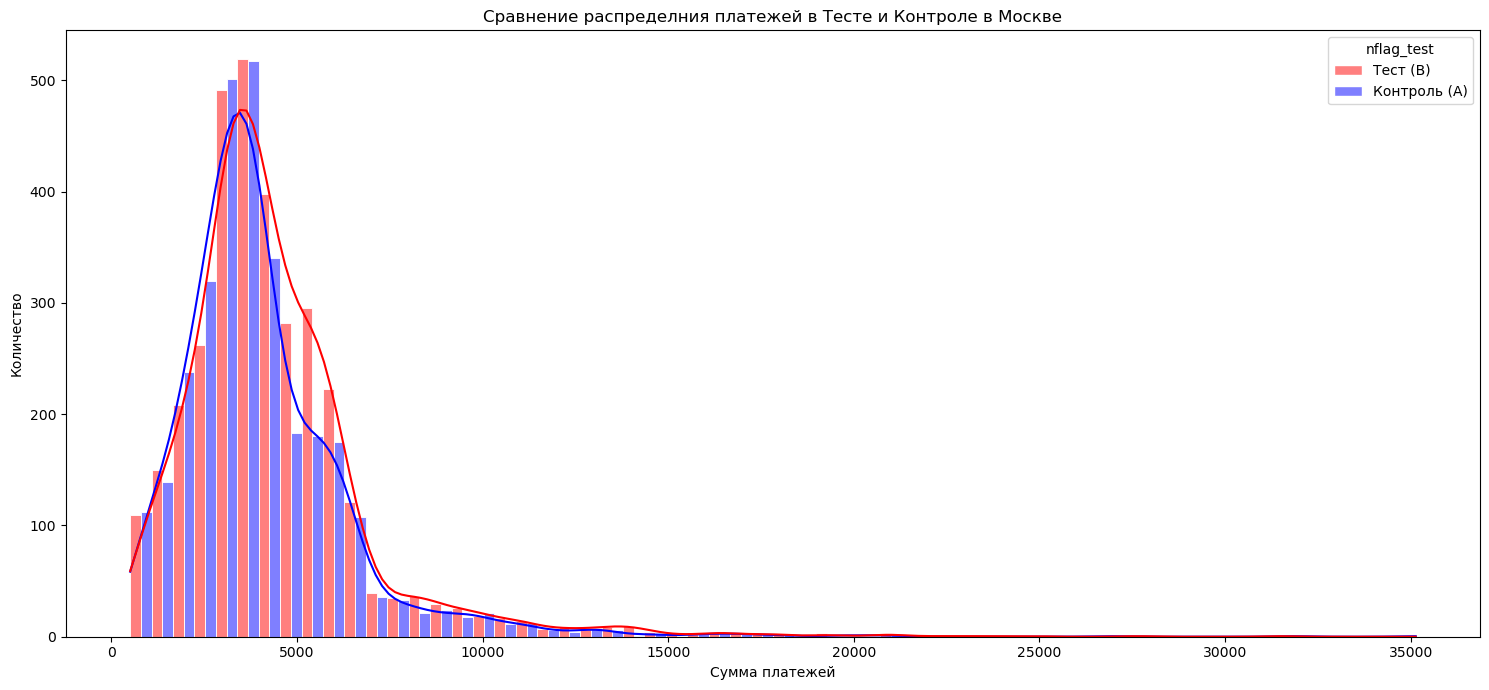

In [30]:
# Строим гистограмму распределния платежей в Москве
plot_pay_Msc = df_Msc[df_Msc['sum_pay'] > 0] # берем данные, где был платеж
plot_df_Msc = plot_pay_Msc.copy()
plot_df_Msc['nflag_test'] = plot_df_Msc['nflag_test'].map({0:'Контроль (А)', 1:'Тест (В)'})
plt.figure(figsize=(15, 7))
sns.histplot(data=plot_df_Msc, 
             x='sum_pay', 
             hue='nflag_test', 
             bins=60, 
             palette={'Контроль (А)':'blue', 'Тест (В)':'red'}, 
             alpha=0.5, 
             edgecolor='white', 
             multiple='dodge',
             kde = True)

plt.title('Сравнение распределния платежей в Тесте и Контроле в Москве')
plt.xlabel('Сумма платежей')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<b>По результатам проведенных вычислений в Москве, видим, что полученные различия в группах не случайны:</b>
<ul> 
    <li> p-value для среднего чека, конверсии, а также для критерия Манна-Уитни по Москве значительно меньше уровня значимости (0,05), т.е. изменения   в тестовой и контрольной группах не случайны и статистически значимы. </li>
      <li>на графике видим, что в тестовой группе количество транзакций со средним чеком выше 4000 руб. выше, чем в контрольной.  </li>
</ul>
</div>

In [31]:
# Проведем стат.анализ в отношении Санкт-Петербурга
df_SPb = df_clean[df_clean['city'] == 'Санкт-Петербург'] # фильтруем по Санкт-Петербургу

print(f'---Тест для города Санкт-Петербург---')
control_pay_SPb = df_SPb[(df_SPb['nflag_test'] == 0)]['sum_pay']
test_pay_SPb = df_SPb[(df_SPb['nflag_test'] == 1)]['sum_pay']

print('---Сравнение средних чеков---')
test_calc(test_pay_SPb, control_pay_SPb)
print()

control_conv_SPb = df_SPb[df_SPb['nflag_test'] == 0]['is_bought']
test_conv_SPb = df_SPb[df_SPb['nflag_test'] == 1]['is_bought']
print('---Сравнение конверсий---')
test_calc(test_conv_SPb, control_conv_SPb)
print()

print('---Сравнение распределение платежей---')
mann_whitney_func(test_pay_SPb, control_pay_SPb)

---Тест для города Санкт-Петербург---
---Сравнение средних чеков---
Разница между средними значениями: 513.9
Количество наблюдений первой выборки 4445
Количество наблюдений второй выборки 4434
Стат.критерий: 8.759635784179547
p value: 2.3198088937974163e-18
Разница статистически значима

---Сравнение конверсий---
Разница между средними значениями: 0.1
Количество наблюдений первой выборки 4445
Количество наблюдений второй выборки 4434
Стат.критерий: 9.352468686561785
p value: 1.065825659919673e-20
Разница статистически значима

---Сравнение распределение платежей---
Стат.критерий: 10899685.5
p value: 2.0392184217953754e-20
Разница в выборках статистически значима


(np.float64(10899685.5), np.float64(2.0392184217953754e-20))

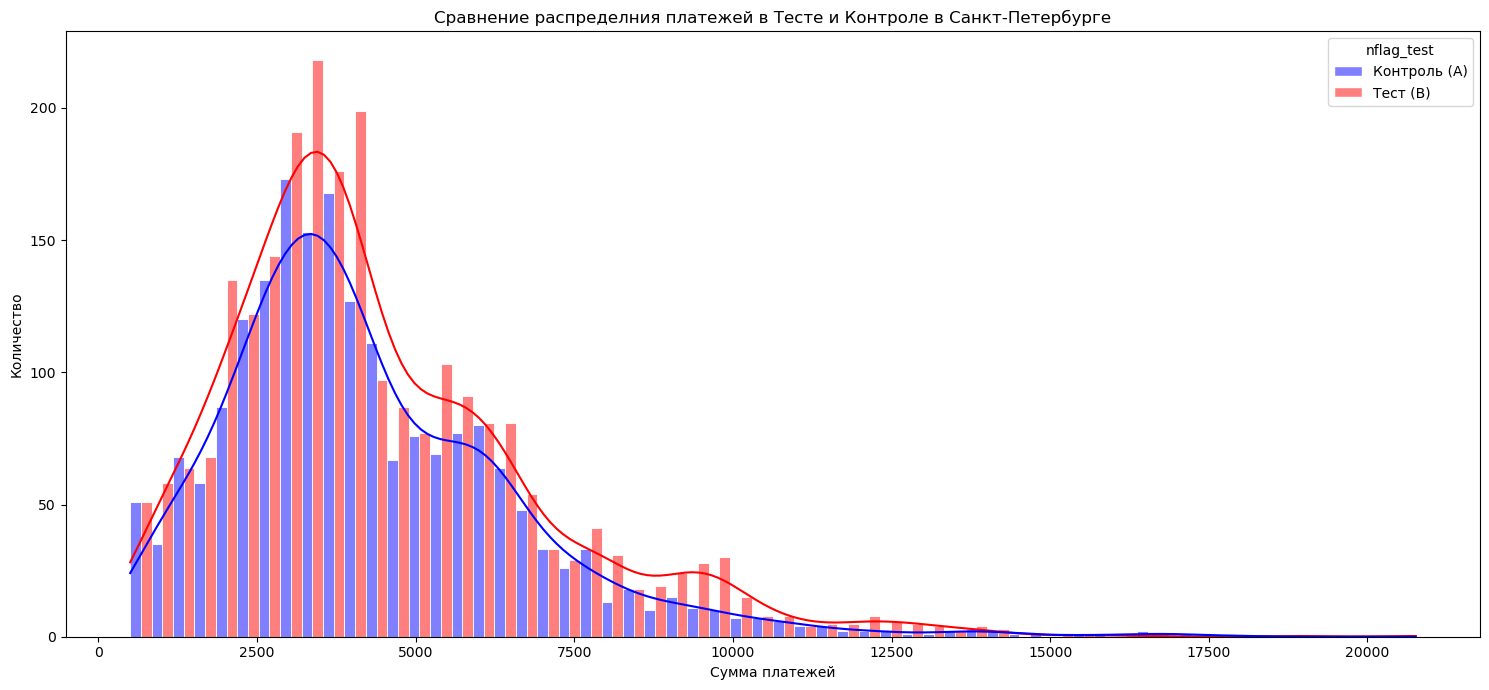

In [32]:
# Строим гистограмму распределния платежей в Санкт-Петербурге
plot_pay_SPb = df_SPb[df_SPb['sum_pay'] > 0] # берем данные, где был платеж
plot_df_SPb = plot_pay_SPb.copy()
plot_df_SPb['nflag_test'] = plot_df_SPb['nflag_test'].map({0:'Контроль (А)', 1:'Тест (В)'})
plt.figure(figsize=(15, 7))
sns.histplot(data=plot_df_SPb, 
             x='sum_pay', 
             hue='nflag_test', 
             bins=60, 
             palette={'Контроль (А)':'blue', 'Тест (В)':'red'}, 
             alpha=0.5, 
             edgecolor='white', 
             multiple='dodge',
             kde = True)

plt.title('Сравнение распределния платежей в Тесте и Контроле в Санкт-Петербурге')
plt.xlabel('Сумма платежей')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<b>По результатам проведенных вычислений в Санкт-Петербурге, видим, что полученные различия в группах не случайны:</b>
<ul> 
    <li> p-value для среднего чека, конверсии, а также для критерия Манна-Уитни в Санкт-Петербурге значительно меньше уровня значимости (0,05), т.е. изменения   в тестовой и контрольной группах не случайны и статистически значимы. </li>
      <li>на графике видим, что в тестовой группе количество транзакций выше, чем в контрольной.  </li>
</ul>
</div>

In [33]:
# Создаём цикл для вычисления статистических показателей по остальным городам
exclude_cities = ['Москва', 'Санкт-Петербург'] # формируем список исключений
df_city = df_clean[~df_clean['city'].isin(exclude_cities)] # исключаем Москву и Санкт-Петербург

for i in df_city['city'].unique():
    print(f'---Тест для города {i}---')
    df_loc = df_city[df_city['city'] == i] # фильтруем по городу

    control_pay = df_loc[(df_loc['nflag_test'] == 0)]['sum_pay']
    test_pay = df_loc[(df_loc['nflag_test'] == 1)]['sum_pay']
    print('---Сравнение средних чеков---')
    test_calc(test_pay, control_pay)
    print()

    control_conv = df_loc[df_loc['nflag_test'] == 0]['is_bought']
    test_conv = df_loc[df_loc['nflag_test'] == 1]['is_bought']
    print('---Сравнение конверсий---')
    test_calc(test_conv, control_conv)
    print()

    print('---Сравнение распределение платежей---')
    mann_whitney_func(test_pay, control_pay)
    print('-'*30)
    print()

---Тест для города Красноярск---
---Сравнение средних чеков---
Разница между средними значениями: 8.72
Количество наблюдений первой выборки 3037
Количество наблюдений второй выборки 2900
Стат.критерий: 0.12000608689929208
p value: 0.9044823881233125
Разница статистически НЕ значима

---Сравнение конверсий---
Разница между средними значениями: -0.0
Количество наблюдений первой выборки 3037
Количество наблюдений второй выборки 2900
Стат.критерий: -0.27863631219717744
p value: 0.7805336501430107
Разница статистически НЕ значима

---Сравнение распределение платежей---
Стат.критерий: 4393882.0
p value: 0.8770469886251647
Нет стат. значимой разницы между выборками
------------------------------

---Тест для города Мурманск---
---Сравнение средних чеков---
Разница между средними значениями: 8.05
Количество наблюдений первой выборки 1055
Количество наблюдений второй выборки 1065
Стат.критерий: 0.06902498862889384
p value: 0.9449762446327565
Разница статистически НЕ значима

---Сравнение конвер

---Тест для города Красноярск---


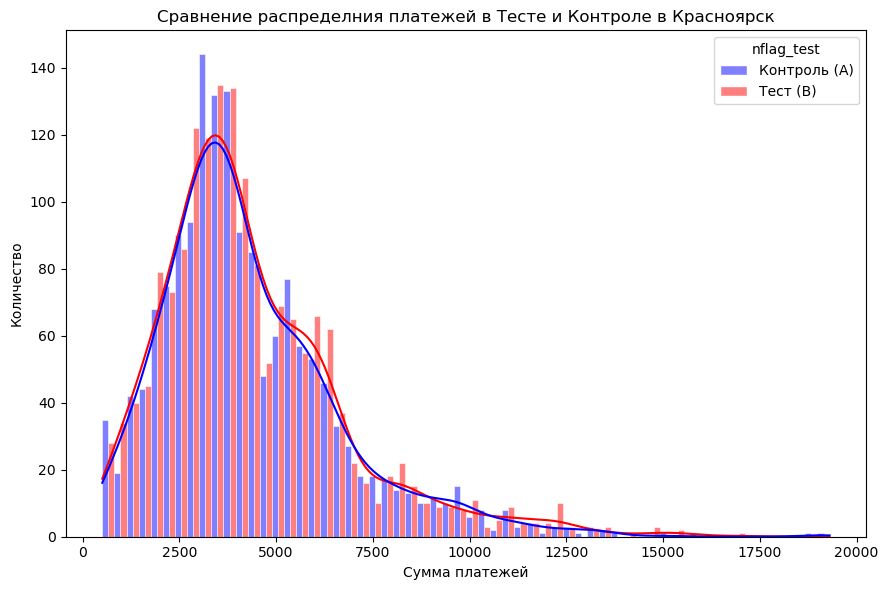

---Тест для города Мурманск---


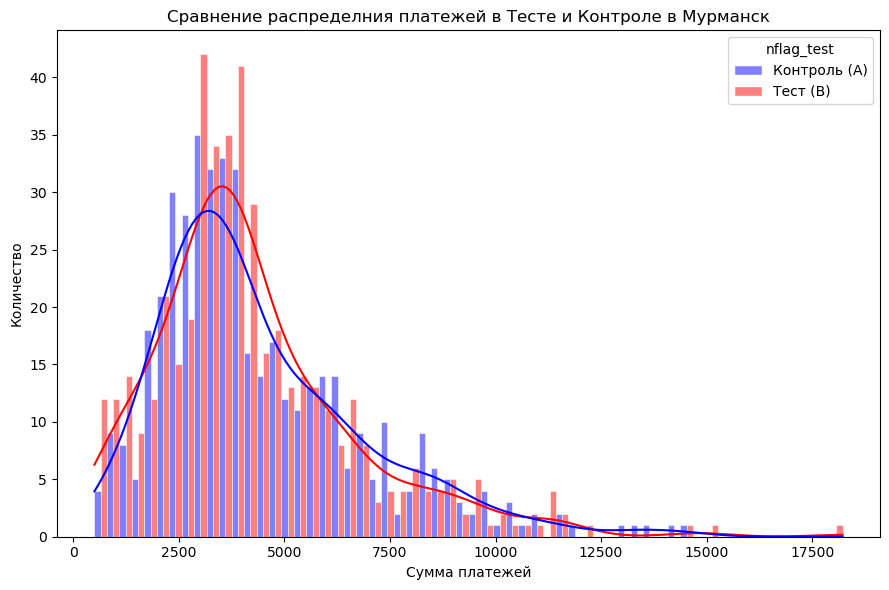

---Тест для города Казань---


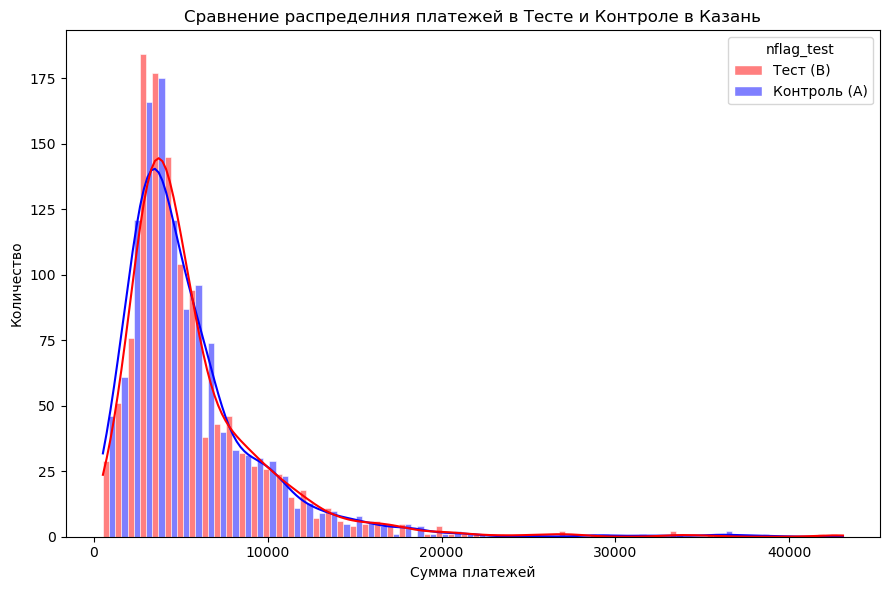

---Тест для города Саратов---


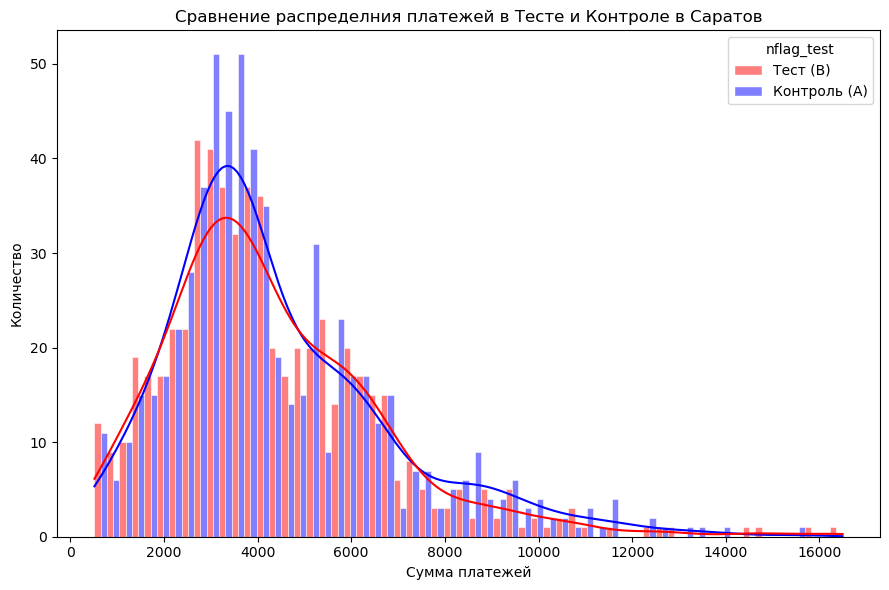

---Тест для города Тольятти---


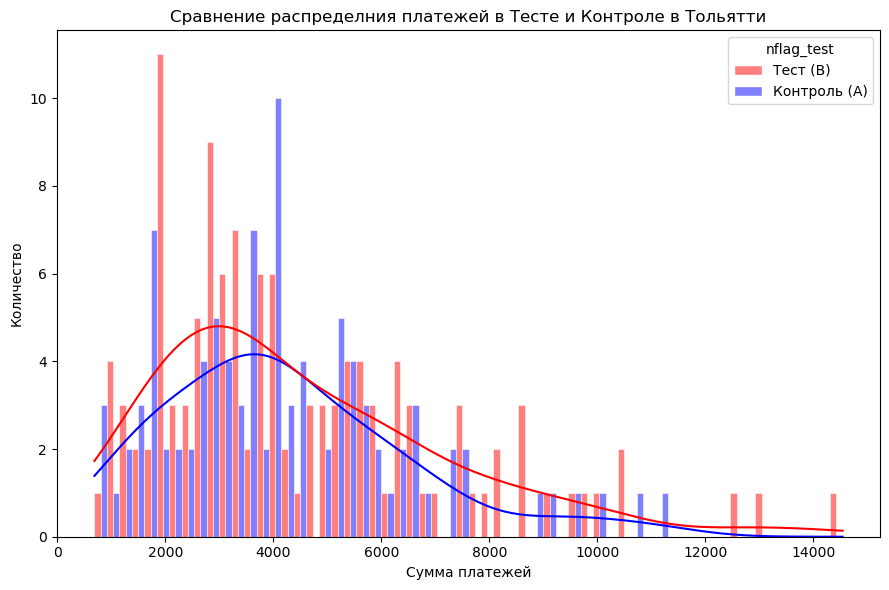

---Тест для города Тюмень---


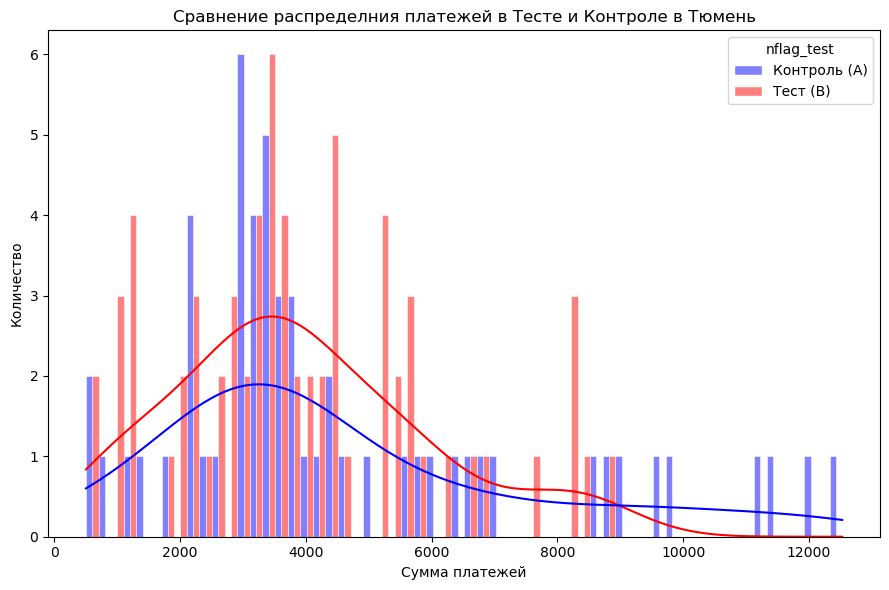

---Тест для города Волгоград---


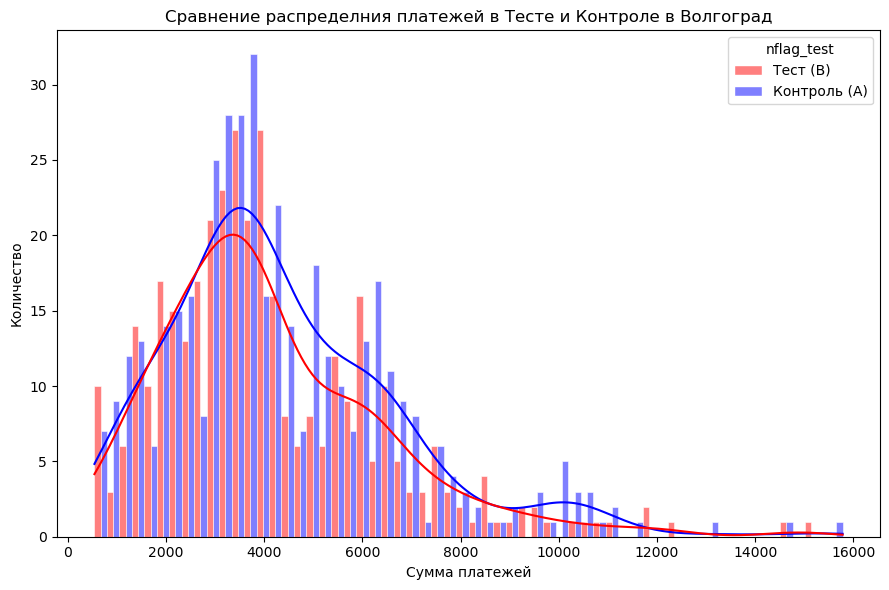

---Тест для города Сочи---


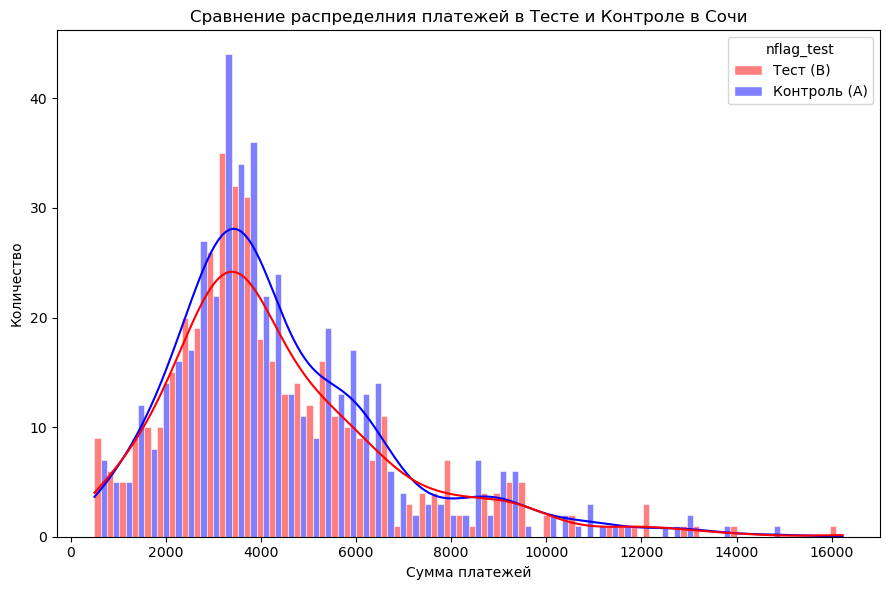

---Тест для города Владимир---


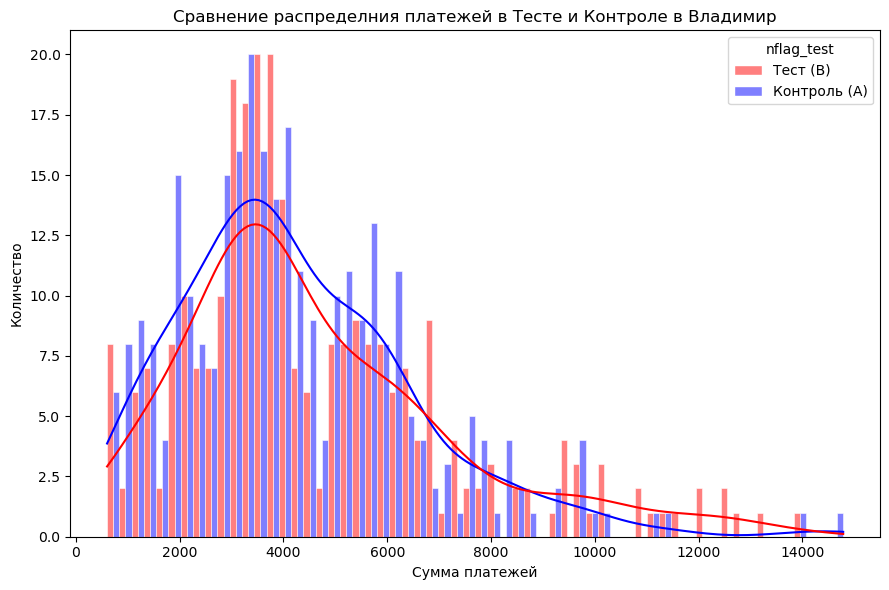

---Тест для города Самара---


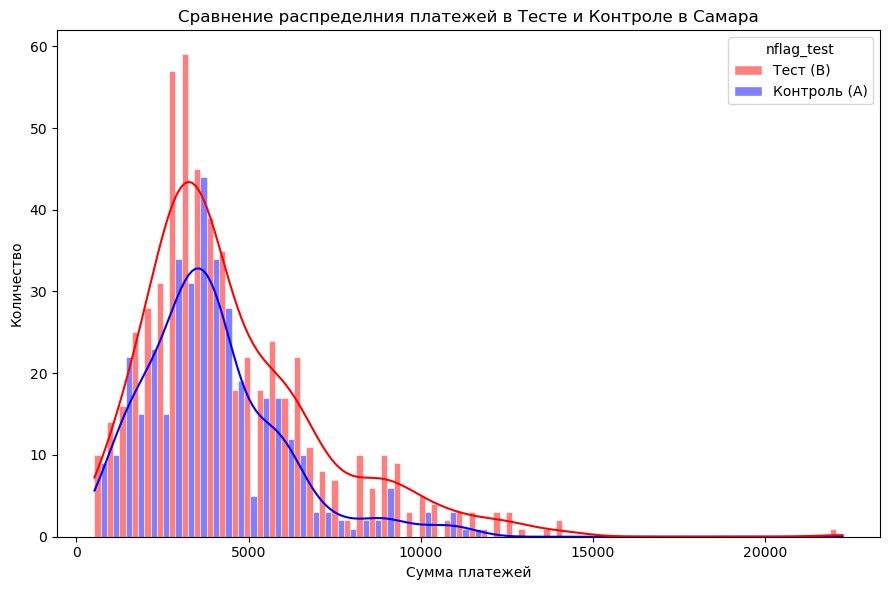

---Тест для города Краснодар---


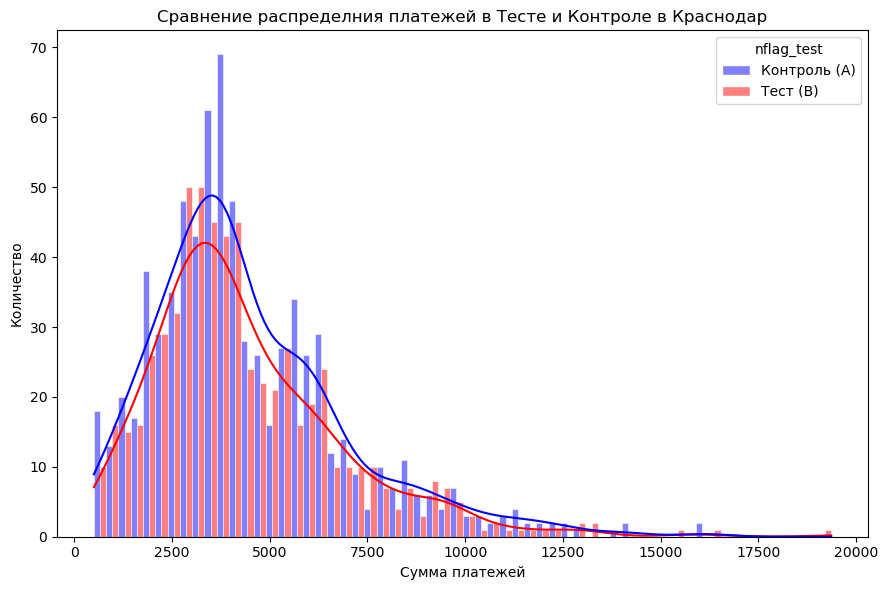

---Тест для города Сахалинск---


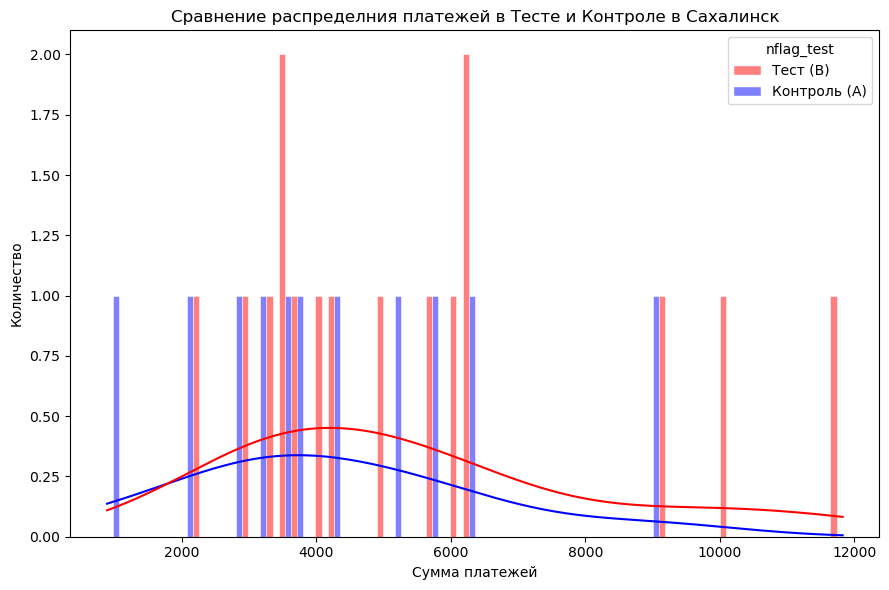

---Тест для города Дмитров---


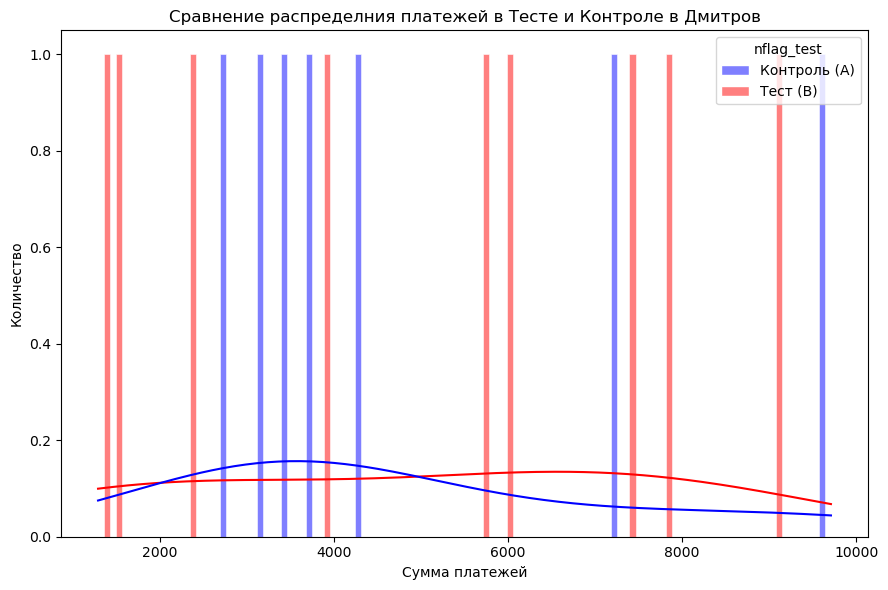

In [34]:
# Строим гистограмму распределния платежей для каждого города
for i in df_city['city'].unique():
    print(f'---Тест для города {i}---')
    df_loc = df_city[df_city['city'] == i] # фильтруем по городу
    plot_pay = df_loc[df_loc['sum_pay'] > 0] # берем данные, где был платеж
    plot_df = plot_pay.copy()
    plot_df['nflag_test'] = plot_df['nflag_test'].map({0:'Контроль (А)', 1:'Тест (В)'})
    plt.figure(figsize=(9, 6))
    sns.histplot(data=plot_df, 
                 x='sum_pay', 
                 hue='nflag_test', 
                 bins=60, 
                 palette={'Контроль (А)':'blue', 'Тест (В)':'red'}, 
                 alpha=0.5, 
                 edgecolor='white', 
                 multiple='dodge',
                 kde = True)
    
    plt.title(f'Сравнение распределния платежей в Тесте и Контроле в {i}')
    plt.xlabel('Сумма платежей')
    plt.ylabel('Количество')
    
    plt.tight_layout()
    plt.show()

<div class="alert alert-block alert-info">
<b>Вывод:</b>
<ul> 
    <li> По результатам теста и графикам видим, что не во всех городах новая механика пуш-уведомлений положительно повлияла на средний чек и конверсию в покупку</li>
    </ul>
</div>


### Сегментация по торговым точкам

In [35]:
pd.options.display.float_format = '{:.2f}'.format
segm_pivot_tp = df_clean.pivot_table(index = ['city', 'id_trading_point', 'nflag_test'],
                                  values = ['id_client', 'is_bought', 'sum_pay'],
                                  aggfunc = {'id_client':'nunique', # кол-во уникальных покупателей
                                             'is_bought':'sum',   # кол-во покупок в группе
                                             'sum_pay':'sum'} # средний чек и выручка
                                 )
# Переименуем столбцы и строки
segm_pivot_tp.columns = ['users', 'purchases', 'revenue']

# Определяем средний чек в отдельный столбец 
segm_pivot_tp['avg_check'] = segm_pivot_tp['revenue']/segm_pivot_tp['purchases']

# Определяем конверсию в отдельный столбец 
segm_pivot_tp['conversion,%'] = segm_pivot_tp['purchases']/segm_pivot_tp['users']*100



segm_pivot_tp

users  purchases    revenue  avg_check  \
city      id_trading_point nflag_test                                           
Владимир  11               0             608        303 1282035.00    4231.14   
                           1             509        280 1296535.00    4630.48   
Волгоград 66               0             703        419 1829038.00    4365.25   
                           1             657        363 1503788.00    4142.67   
Дмитров   2                0              71          7   34325.00    4903.57   
...                                      ...        ...        ...        ...   
Сочи      73               1             187         95  391238.00    4118.29   
Тольятти  88               0             167         97  407390.00    4199.90   
                           1             190        122  551458.00    4520.15   
Тюмень    19               0             146         55  254533.00    4627.87   
                           1             130         68  265697.00    3907.31   

                                       conversion,%  
city      id_trading_point nflag_test                
Владимир  11               0                  49.84  
                           1                  55.01  
Волгоград 66               0                  59.60  
                           1                  55.25  
Дмитров   2                0                   9.86  
...                                             ...  
Сочи      73               1                  50.80  
Тольятти  88               0                  58.08  
                           1                  64.21  
Тюмень    19               0                  37.67  
                           1                  52.31  

[102 rows x 5 columns]

In [36]:
# Создаем двойной цикл 
for i in df_clean['city'].unique():
    print(f'--- Тест для города {i} ---')
    df_loc1 = df_clean[df_clean['city']==i] # фильтруем данные по городу
    for t in df_loc1['id_trading_point'].unique():
        print(f'---Тест для торговой точки № {t}---')
        df_loc2 = df_loc1[df_loc1['id_trading_point'] == t] # фильтруем по торговой точке
        
        control_pay = df_loc2[(df_loc2['nflag_test'] == 0)]['sum_pay']
        test_pay = df_loc2[(df_loc2['nflag_test'] == 1)]['sum_pay']
        print('---Сравнение средних чеков---')
        test_calc(test_pay, control_pay)
        print()
        
        control_conv = df_loc2[df_loc2['nflag_test'] == 0]['is_bought']
        test_conv = df_loc2[df_loc2['nflag_test'] == 1]['is_bought']
        print('---Сравнение конверсий---')
        test_calc(test_conv, control_conv)
        print()
        
        print('---Сравнение распределение платежей---')
        mann_whitney_func(test_pay, control_pay)
        print('-'*30)
        print()

--- Тест для города Красноярск ---
---Тест для торговой точки № 212---
---Сравнение средних чеков---
Разница между средними значениями: -77.74
Количество наблюдений первой выборки 593
Количество наблюдений второй выборки 575
Стат.критерий: -0.4835853855099397
p value: 0.6287709476405416
Разница статистически НЕ значима

---Сравнение конверсий---
Разница между средними значениями: 0.01
Количество наблюдений первой выборки 593
Количество наблюдений второй выборки 575
Стат.критерий: 0.45097452672124133
p value: 0.6520917611862189
Разница статистически НЕ значима

---Сравнение распределение платежей---
Стат.критерий: 169439.0
p value: 0.8468854097705489
Нет стат. значимой разницы между выборками
------------------------------

---Тест для торговой точки № 278---
---Сравнение средних чеков---
Разница между средними значениями: 314.13
Количество наблюдений первой выборки 535
Количество наблюдений второй выборки 489
Стат.критерий: 1.8202681201948652
p value: 0.06901056074583502
Разница статис

In [37]:
display(df_clean['id_trading_point'].nunique())
display(df_clean['city'].nunique())

51

15

### Отчет по A/B-тесту

In [38]:
# Создаем список для хранения в нем результатов анализа по каждой торговой точке (т.т.)
trading_point_results = []

# Запустим цикл стат. анализа среднего чека для каждой уникальной т.т.
for tp in df_clean['id_trading_point'].unique():
    df_tp = df_clean[df_clean['id_trading_point'] == tp] # фильтруем по т.т.
    
    c_pay = df_tp[(df_tp['nflag_test'] == 0)]['sum_pay'] # данные для анализа чека в контрольной группе (только покупки)
    t_pay = df_tp[(df_tp['nflag_test'] == 1)]['sum_pay'] # данные для анализа чека в тестовой группе (только покупки)

   
    # Определяем стат. критерий и p-value для сравнения средних чеков 
    s, p_st  = ttest_ind(t_pay, c_pay)
   
    # Вычисляем значения для финальной таблицы
    city_name = df_tp['city'].iloc[0] # определяем город т.т.
    cnt_test = len(df_tp[(df_tp['nflag_test'] == 1)])
    cnt_control = len(df_tp[(df_tp['nflag_test'] == 0)])
    cnt_all = cnt_test+cnt_control
    percent_cnt = cnt_all/len(df_clean)*100
    avg_pay_test = t_pay.mean()
    avg_pay_control = c_pay.mean()
    diff = avg_pay_test-avg_pay_control
    std_test = t_pay.std()
    std_control = c_pay.std()

    # Собираем данные в одну библиотеку
    trading_point_results.append({'city':city_name,
                                  'id_trading_point':tp,
                                  'count_test':cnt_test,
                                  'count_control':cnt_control,
                                  'count_all':cnt_all,
                                  'percent_count':percent_cnt,
                                  'avg_payment_test':avg_pay_test,
                                  'avg_payment_control':avg_pay_control,
                                  'diff':diff,
                                  'sigma_test':std_test,
                                  'sigma_control':std_control,
                                  'ttest':s,
                                  'pvalue_ttest':p_st                                         
                                 })
    
# Превращаем библиотеку в таблицу
df_tp_report = pd.DataFrame(trading_point_results)

In [39]:
df_final =df_tp_report.sort_values('city').reset_index(drop=True)

In [40]:
# Пропишем условия для добавления флага с результатом эксперимента 
conditions = [(df_final['diff']> 0) & (df_final['pvalue_ttest'] <= 0.05),
              (df_final['diff'] < 0) & (df_final['pvalue_ttest'] <= 0.05)]

# Пропишем название результата эксперимента 
choices = ['Growth', 'Decline']

# Создаем столбец для указания флага с результатом эксперимента по каждой т.т.
df_final['Conclusion'] = np.select(conditions, choices, default = 'No Change')   
df_final

,city,id_trading_point,count_test,count_control,count_all,percent_count,avg_payment_test,avg_payment_control,diff,sigma_test,sigma_control,ttest,pvalue_ttest,Conclusion
0,Владимир,11,509,608,1117,2.46,2547.22,2108.61,438.61,3023.70,2663.04,2.58,0.01,Growth
1,Волгоград,66,657,703,1360,3.00,2288.87,2601.76,-312.89,2682.57,2830.19,-2.09,0.04,Decline
2,Дмитров,2,78,71,149,0.33,579.33,483.45,95.88,1860.76,1654.92,0.33,0.74,No Change
3,Казань,439,355,351,706,1.56,2481.96,2400.64,81.33,4040.44,3722.12,0.28,0.78,No Change
4,Казань,991,270,294,564,1.24,3249.28,2452.99,796.30,4719.59,3633.94,2.26,0.02,Growth
5,Казань,699,482,494,976,2.15,2422.29,2574.35,-152.07,3906.82,4082.85,-0.59,0.55,No Change
6,Казань,477,382,386,768,1.69,2259.62,2496.99,-237.36,3482.85,3881.99,-0.89,0.37,No Change
7,Казань,544,377,416,793,1.75,2621.43,2635.55,-14.12,3714.89,4639.82,-0.05,0.96,No Change
8,Казань,516,634,636,1270,2.80,3245.20,2880.48,364.72,4543.17,3819.29,1.55,0.12,No Change
9,Краснодар,1989,239,270,509,1.12,4407.38,4163.96,243.43,2737.90,2492.10,1.05,0.29,No Change


In [41]:
# Выгружаем полученную таблицу в Excel
with pd.ExcelWriter('Final.xlsx') as writer:
    df_final[df_final['Conclusion'] == 'Growth'].to_excel(writer, sheet_name = 'Growth', index=False)
    df_final[df_final['Conclusion'] == 'Decline'].to_excel(writer, sheet_name = 'Decline', index=False)
    df_final[df_final['Conclusion'] == 'No Change'].to_excel(writer, sheet_name = 'No Change', index=False)